# 1. Assignment Overview

Cell này làm gì?

Notebook này tiếp tục bài toán A03 Diabetes: dùng đặc trưng sức khỏe của bệnh nhân/người trả lời khảo sát để dự đoán `Diabetes_binary`. A04 dùng dataset BRFSS 2021 unbalanced đã chuẩn bị trong `datasets/diabetes/a04`, tập trung vào deep learning trên dữ liệu tabular và so sánh cẩn thận với A03.


In [1]:
from pathlib import Path
import json
import pandas as pd


def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for path in [start.resolve(), *start.resolve().parents]:
        if (path / "datasets" / "diabetes" / "a04").exists() and (
            path / "pipeline"
        ).exists():
            return path
    raise FileNotFoundError(
        "Cannot locate project root from current working directory."
    )


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "datasets" / "diabetes" / "a04"
A03_NOTEBOOK = PROJECT_ROOT / "pipeline" / "diabetes_pipeline.ipynb"
A03_METADATA_PATH = PROJECT_ROOT / "pipeline" / "diabetes" / "metadata.json"
A03_COMPARISON_PATH = PROJECT_ROOT / "pipeline" / "diabetes" / "final_comparison.csv"
A04_METADATA_PATH = DATA_DIR / "metadata.json"

with A04_METADATA_PATH.open("r", encoding="utf-8") as f:
    dataset_metadata = json.load(f)

overview = {
    "A03 task": "Binary diabetes classification from health indicators",
    "A03 target": "Diabetes_binary",
    "A03 notebook exists": A03_NOTEBOOK.exists(),
    "A04 dataset": dataset_metadata["dataset_name"],
    "A04 source": dataset_metadata["source"],
    "A04 target": dataset_metadata["target"],
    "A04 samples": dataset_metadata["samples"],
    "A04 features": dataset_metadata["features"],
    "Task type": "Binary classification",
}
pd.DataFrame([overview]).T.rename(columns={0: "Value"})

,Value
A03 task,Binary diabetes classification from health ind...
A03 target,Diabetes_binary
A03 notebook exists,True
A04 dataset,BRFSS 2021 Diabetes Health Indicators - Binary...
A04 source,Kaggle dataset cleaned from CDC BRFSS 2021
A04 target,Diabetes_binary
A04 samples,236378
A04 features,21
Task type,Binary classification


Output cho thấy điều gì?

Bảng xác nhận notebook giữ đúng continuity với A03: cùng target `Diabetes_binary`, cùng domain patient health indicators, nhưng chuyển sang dataset A04 BRFSS 2021 lớn hơn và mất cân bằng hơn.


# 2. Environment Setup

Cell này làm gì?

Import thư viện, cố định seed, kiểm tra TensorFlow/PyTorch version và thiết bị chạy. Notebook dùng `pathlib.Path` để tránh hard-code đường dẫn cá nhân.


In [2]:
import os
import random
import time
import warnings
from datetime import datetime, timezone

import joblib
import matplotlib.pyplot as plt
import numpy as np
import sklearn
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore", category=FutureWarning)

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.get_logger().setLevel("ERROR")
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

ARTIFACT_DIR = PROJECT_ROOT / "pipeline04" / "diabetes"
MODEL_DIR = ARTIFACT_DIR / "models"
METRIC_DIR = ARTIFACT_DIR / "metrics"
FIGURE_DIR = ARTIFACT_DIR / "figures"
for directory in [ARTIFACT_DIR, MODEL_DIR, METRIC_DIR, FIGURE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

env_info = {
    "Python executable": Path(os.sys.executable).name,
    "NumPy": np.__version__,
    "Pandas": pd.__version__,
    "scikit-learn": sklearn.__version__,
    "TensorFlow": tf.__version__,
    "PyTorch": torch.__version__,
    "TensorFlow GPUs": len(tf.config.list_physical_devices("GPU")),
    "PyTorch device": str(DEVICE),
    "Project root is portable": PROJECT_ROOT.name == "assign",
}
pd.DataFrame([env_info]).T.rename(columns={0: "Value"})

,Value
Python executable,python.exe
NumPy,1.26.4
Pandas,2.2.3
scikit-learn,1.5.2
TensorFlow,2.18.0
PyTorch,2.5.1+cpu
TensorFlow GPUs,0
PyTorch device,cpu
Project root is portable,True


Output cho thấy điều gì?

Environment có đủ TensorFlow và PyTorch để chạy cùng một pipeline dữ liệu. Nếu device là CPU thì notebook vẫn hợp lệ vì mô hình tabular nhỏ và batch size được chọn để chạy được trên laptop/Colab.


# 3. Load Dataset

Cell này làm gì?

Đọc raw CSV A04 từ `datasets/diabetes/a04` và giữ nguyên file raw. Mọi cleaning/preprocessing chỉ thực hiện trong DataFrame làm việc.


In [3]:
csv_files = sorted(DATA_DIR.glob("*.csv"))
raw_files = [
    {
        "file": path.relative_to(PROJECT_ROOT).as_posix(),
        "size_mb": round(path.stat().st_size / (1024 * 1024), 2),
    }
    for path in csv_files
]
display(pd.DataFrame(raw_files))

DATA_PATH = DATA_DIR / "diabetes_binary_health_indicators_BRFSS2021.csv"
TARGET = "Diabetes_binary"
df_raw = pd.read_csv(DATA_PATH)

print("Loaded dataset:", DATA_PATH.relative_to(PROJECT_ROOT).as_posix())
print("Shape:", df_raw.shape)
display(df_raw.head())

,file,size_mb
0,datasets/diabetes/a04/diabetes_binary_health_i...,16.18


Loaded dataset: datasets/diabetes/a04/diabetes_binary_health_indicators_BRFSS2021.csv
Shape: (236378, 22)


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,0,1.0,1,15.0,1.0,0.0,0.0,0,1,...,1,0.0,5.0,10.0,20.0,0.0,0,11,4.0,5.0
1,1.0,1,0.0,1,28.0,0.0,0.0,1.0,0,1,...,1,0.0,2.0,0.0,0.0,0.0,0,11,4.0,3.0
2,1.0,1,1.0,1,33.0,0.0,0.0,0.0,1,1,...,1,0.0,2.0,10.0,0.0,0.0,0,9,4.0,7.0
3,1.0,0,1.0,1,29.0,0.0,1.0,1.0,1,1,...,1,0.0,5.0,0.0,30.0,1.0,1,12,3.0,4.0
4,0.0,0,0.0,1,24.0,1.0,0.0,0.0,0,0,...,1,0.0,3.0,0.0,0.0,1.0,1,13,5.0,6.0


Output cho thấy điều gì?

Dataset được đọc từ path tương đối trong project. Shape là số dòng raw và số cột trước khi xử lý duplicate, còn `head()` xác nhận các feature đều là health indicators dạng numeric-coded tabular.


# 4. Dataset Inspection

Cell này làm gì?

Kiểm tra schema, missing values, duplicates, target distribution, descriptive statistics và các vấn đề dữ liệu rõ ràng của Diabetes.


,Metric,Value
0,Rows,236378
1,Columns,22
2,Feature columns,21


,Column,Dtype
0,Diabetes_binary,float64
1,HighBP,int64
2,HighChol,float64
3,CholCheck,int64
4,BMI,float64
5,Smoker,float64
6,Stroke,float64
7,HeartDiseaseorAttack,float64
8,PhysActivity,int64
9,Fruits,int64


,Missing
0,No missing values detected


Duplicate rows: 13135


,Class,Count,Rate
0,0,202810,0.858
1,1,33568,0.142


,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,236378.0,0.142,0.349,0.0,0.0,0.0,0.0,1.0
HighBP,236378.0,0.419,0.493,0.0,0.0,0.0,1.0,1.0
HighChol,236378.0,0.402,0.490,0.0,0.0,0.0,1.0,1.0
CholCheck,236378.0,0.963,0.188,0.0,1.0,1.0,1.0,1.0
BMI,236378.0,28.954,6.552,12.0,24.0,28.0,32.0,99.0
Smoker,236378.0,0.412,0.492,0.0,0.0,0.0,1.0,1.0
Stroke,236378.0,0.039,0.193,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,236378.0,0.087,0.281,0.0,0.0,0.0,0.0,1.0
PhysActivity,236378.0,0.779,0.415,0.0,1.0,1.0,1.0,1.0
Fruits,236378.0,0.621,0.485,0.0,0.0,1.0,1.0,1.0


,Column,ZeroCount,Min,Max
0,BMI,0,12.0,99.0
1,MentHlth,147300,0.0,30.0
2,PhysHlth,156784,0.0,30.0


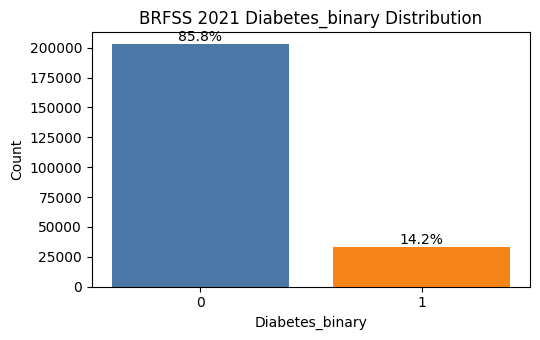

In [4]:
shape_info = pd.DataFrame(
    {
        "Metric": ["Rows", "Columns", "Feature columns"],
        "Value": [df_raw.shape[0], df_raw.shape[1], df_raw.shape[1] - 1],
    }
)

dtype_info = df_raw.dtypes.astype(str).reset_index()
dtype_info.columns = ["Column", "Dtype"]

missing = df_raw.isna().sum().reset_index()
missing.columns = ["Column", "MissingCount"]
missing["MissingRate"] = missing["MissingCount"] / len(df_raw)

duplicate_count = int(df_raw.duplicated().sum())
target_counts = df_raw[TARGET].value_counts().sort_index()
target_distribution = pd.DataFrame(
    {
        "Class": target_counts.index.astype(int),
        "Count": target_counts.values,
        "Rate": (target_counts.values / len(df_raw)).round(4),
    }
)

clinical_zero_checks = ["BMI", "MentHlth", "PhysHlth"]
zero_check = pd.DataFrame(
    {
        "Column": clinical_zero_checks,
        "ZeroCount": [int((df_raw[col] == 0).sum()) for col in clinical_zero_checks],
        "Min": [float(df_raw[col].min()) for col in clinical_zero_checks],
        "Max": [float(df_raw[col].max()) for col in clinical_zero_checks],
    }
)

display(shape_info)
display(dtype_info)
display(
    missing[missing["MissingCount"] > 0]
    if missing["MissingCount"].sum()
    else pd.DataFrame({"Missing": ["No missing values detected"]})
)
print("Duplicate rows:", duplicate_count)
display(target_distribution)
display(df_raw.describe().T.round(3))
display(zero_check)

fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.bar(
    target_distribution["Class"].astype(str),
    target_distribution["Count"],
    color=["#4C78A8", "#F58518"],
)
ax.set_title("BRFSS 2021 Diabetes_binary Distribution")
ax.set_xlabel("Diabetes_binary")
ax.set_ylabel("Count")
for i, row in target_distribution.iterrows():
    ax.text(i, row["Count"], f'{row["Rate"]:.1%}', ha="center", va="bottom")
fig.tight_layout()
target_fig_path = FIGURE_DIR / "target_distribution.png"
fig.savefig(target_fig_path, dpi=160)
plt.show()

Output cho thấy điều gì?

Dataset A04 không có missing values nhưng có duplicate rows và class imbalance rõ: class 0 chiếm đa số. BMI không có giá trị 0 vô lý; `MentHlth` và `PhysHlth` có 0 hợp lệ vì đó là số ngày sức khỏe kém trong tháng.


# 5. Data Preparation

Cell này làm gì?

Loại exact duplicates trước split để tránh duplicate leakage, chia train/validation/test theo stratify, rồi fit imputer/scaler chỉ trên training data.


In [5]:
df_clean = df_raw.drop_duplicates().reset_index(drop=True)
feature_cols = [col for col in df_clean.columns if col != TARGET]
numerical_features = feature_cols.copy()
categorical_features = []

X = df_clean[feature_cols]
y = df_clean[TARGET].astype(int)

X_train_raw, X_temp_raw, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=SEED,
    stratify=y,
)
X_valid_raw, X_test_raw, y_valid, y_test = train_test_split(
    X_temp_raw,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp,
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            numerical_features,
        )
    ],
    remainder="drop",
)

X_train = preprocessor.fit_transform(X_train_raw).astype("float32")
X_valid = preprocessor.transform(X_valid_raw).astype("float32")
X_test = preprocessor.transform(X_test_raw).astype("float32")
y_train_np = y_train.to_numpy(dtype="float32")
y_valid_np = y_valid.to_numpy(dtype="float32")
y_test_np = y_test.to_numpy(dtype="float32")

joblib.dump(preprocessor, MODEL_DIR / "preprocessor.joblib")

split_summary = pd.DataFrame(
    [
        {
            "Split": "train",
            "Rows": len(y_train),
            "PositiveRate": y_train.mean(),
            "Negative": int((y_train == 0).sum()),
            "Positive": int((y_train == 1).sum()),
        },
        {
            "Split": "validation",
            "Rows": len(y_valid),
            "PositiveRate": y_valid.mean(),
            "Negative": int((y_valid == 0).sum()),
            "Positive": int((y_valid == 1).sum()),
        },
        {
            "Split": "test",
            "Rows": len(y_test),
            "PositiveRate": y_test.mean(),
            "Negative": int((y_test == 0).sum()),
            "Positive": int((y_test == 1).sum()),
        },
    ]
)

scale_check = pd.DataFrame(
    {
        "Feature": numerical_features,
        "TrainScaledMean": X_train.mean(axis=0).round(4),
        "TrainScaledStd": X_train.std(axis=0).round(4),
    }
)

print("Rows before duplicate removal:", len(df_raw))
print("Rows after duplicate removal:", len(df_clean))
print("Removed duplicates:", len(df_raw) - len(df_clean))
display(split_summary)
display(scale_check.head(10))

Rows before duplicate removal: 236378
Rows after duplicate removal: 223243
Removed duplicates: 13135


,Split,Rows,PositiveRate,Negative,Positive
0,train,156270,0.149587,132894,23376
1,validation,33486,0.149585,28477,5009
2,test,33487,0.149610,28477,5010


,Feature,TrainScaledMean,TrainScaledStd
0,HighBP,0.0,1.0
1,HighChol,0.0,1.0
2,CholCheck,-0.0,1.0
3,BMI,0.0,1.0
4,Smoker,-0.0,1.0
5,Stroke,0.0,1.0
6,HeartDiseaseorAttack,0.0,1.0
7,PhysActivity,0.0,1.0
8,Fruits,-0.0,1.0
9,Veggies,0.0,1.0


Output cho thấy điều gì?

Split giữ tỷ lệ class gần như giống nhau nhờ stratify. Preprocessor đã `fit` trên train rồi mới transform validation/test, nên không đưa thông tin từ validation/test vào bước scaling.


# 6. Deep-Learning Data Representation

Cell này làm gì?

In shape của tensor đầu vào deep learning và đánh giá representation có phù hợp với CNN không.


In [6]:
representation_summary = pd.DataFrame(
    {
        "Array": ["X_train", "y_train", "X_valid", "y_valid", "X_test", "y_test"],
        "Shape": [
            X_train.shape,
            y_train_np.shape,
            X_valid.shape,
            y_valid_np.shape,
            X_test.shape,
            y_test_np.shape,
        ],
        "Meaning": [
            "(samples, features)",
            "(samples,)",
            "(samples, features)",
            "(samples,)",
            "(samples, features)",
            "(samples,)",
        ],
    }
)
display(representation_summary)

cnn_suitability = pd.DataFrame(
    [
        {
            "Question": "Raw representation",
            "Assessment": "Tabular vector of survey/health indicators",
        },
        {
            "Question": "Natural baseline",
            "Assessment": "MLP/DNN, because each sample is a fixed feature vector",
        },
        {
            "Question": "CNN justified?",
            "Assessment": "No production CNN: feature columns do not have a stable spatial or local sequential order",
        },
        {
            "Question": "CNN usage in this notebook",
            "Assessment": "Only toy Conv1D operations for assignment discovery, not final modeling",
        },
    ]
)
display(cnn_suitability)

,Array,Shape,Meaning
0,X_train,"(156270, 21)","(samples, features)"
1,y_train,"(156270,)","(samples,)"
2,X_valid,"(33486, 21)","(samples, features)"
3,y_valid,"(33486,)","(samples,)"
4,X_test,"(33487, 21)","(samples, features)"
5,y_test,"(33487,)","(samples,)"


,Question,Assessment
0,Raw representation,Tabular vector of survey/health indicators
1,Natural baseline,"MLP/DNN, because each sample is a fixed featur..."
2,CNN justified?,No production CNN: feature columns do not have...
3,CNN usage in this notebook,Only toy Conv1D operations for assignment disc...


Output cho thấy điều gì?

`X_train` có dạng `(samples, features)`: mỗi dòng là một người trả lời khảo sát, mỗi cột là một biến sức khỏe. Vì các cột không tạo thành ảnh hay chuỗi có thứ tự lân cận tự nhiên, MLP là baseline đúng phương pháp hơn CNN.


# 7. Discover Neural Network and CNN Operations

Cell này làm gì?

Minh họa các operation nhỏ: Dense/Linear, ReLU, logits, sigmoid, Conv1D và pooling trên toy tensors.


In [7]:
toy_x = tf.constant([[1.0, -2.0, 0.5]], dtype=tf.float32)
dense = keras.Sequential(
    [
        layers.Input(shape=(3,)),
        layers.Dense(
            2, use_bias=True, kernel_initializer="ones", bias_initializer="zeros"
        ),
    ]
)
toy_logits = dense(toy_x)
toy_relu = tf.nn.relu(toy_logits)
toy_sigmoid = tf.nn.sigmoid(toy_logits)

toy_seq = tf.reshape(tf.range(1, 9, dtype=tf.float32), (1, 8, 1))
conv = layers.Conv1D(filters=2, kernel_size=3, padding="valid", activation="relu")
conv_out = conv(toy_seq)
pool_out = layers.MaxPooling1D(pool_size=2)(conv_out)

operation_shapes = pd.DataFrame(
    [
        {
            "Object": "toy_x",
            "Shape": tuple(toy_x.shape),
            "Meaning": "one sample, three features",
        },
        {
            "Object": "Dense logits",
            "Shape": tuple(toy_logits.shape),
            "Meaning": "linear outputs before probability",
        },
        {
            "Object": "ReLU(logits)",
            "Shape": tuple(toy_relu.shape),
            "Meaning": "negative values clipped to zero",
        },
        {
            "Object": "Sigmoid(logits)",
            "Shape": tuple(toy_sigmoid.shape),
            "Meaning": "values mapped to 0..1",
        },
        {
            "Object": "Toy sequence",
            "Shape": tuple(toy_seq.shape),
            "Meaning": "(batch, steps, channels)",
        },
        {
            "Object": "Conv1D output",
            "Shape": tuple(conv_out.shape),
            "Meaning": "local windows over toy sequence",
        },
        {
            "Object": "Pooling output",
            "Shape": tuple(pool_out.shape),
            "Meaning": "downsampled Conv1D features",
        },
    ]
)
display(operation_shapes)
print("Dense logits:", toy_logits.numpy().round(4))
print("Sigmoid probabilities:", toy_sigmoid.numpy().round(4))

,Object,Shape,Meaning
0,toy_x,"(1, 3)","one sample, three features"
1,Dense logits,"(1, 2)",linear outputs before probability
2,ReLU(logits),"(1, 2)",negative values clipped to zero
3,Sigmoid(logits),"(1, 2)",values mapped to 0..1
4,Toy sequence,"(1, 8, 1)","(batch, steps, channels)"
5,Conv1D output,"(1, 6, 2)",local windows over toy sequence
6,Pooling output,"(1, 3, 2)",downsampled Conv1D features


Dense logits: [[-0.5 -0.5]]
Sigmoid probabilities: [[0.3775 0.3775]]


Output cho thấy điều gì?

Dense biến vector feature thành logits; sigmoid chuyển logits sang xác suất cho binary classification. Conv1D/pooling chỉ được minh họa trên toy sequence có thứ tự, không áp đặt lên BRFSS tabular features.


# 8. Neural Network / CNN From Scratch

Cell này làm gì?

Tự implement bằng NumPy các operation giáo dục: linear layer, ReLU, sigmoid, binary cross entropy, forward composition và Conv1D toy.


In [8]:
def linear_np(x, w, b):
    return x @ w + b


def relu_np(x):
    return np.maximum(0, x)


def sigmoid_np(x):
    return 1.0 / (1.0 + np.exp(-x))


def binary_cross_entropy_np(y_true, y_prob, eps=1e-7):
    y_prob = np.clip(y_prob, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_prob) + (1 - y_true) * np.log(1 - y_prob))


def forward_np(x, params):
    z1 = linear_np(x, params["w1"], params["b1"])
    a1 = relu_np(z1)
    z2 = linear_np(a1, params["w2"], params["b2"])
    return sigmoid_np(z2)


def conv1d_valid_np(sequence, kernel, bias=0.0):
    sequence = np.asarray(sequence, dtype=float)
    kernel = np.asarray(kernel, dtype=float)
    out = []
    for i in range(len(sequence) - len(kernel) + 1):
        out.append(float(np.sum(sequence[i : i + len(kernel)] * kernel) + bias))
    return np.asarray(out)


rng = np.random.default_rng(SEED)
toy_batch = X_train[:4]
params = {
    "w1": rng.normal(0, 0.1, size=(X_train.shape[1], 5)),
    "b1": np.zeros(5),
    "w2": rng.normal(0, 0.1, size=(5, 1)),
    "b2": np.zeros(1),
}
toy_probs = forward_np(toy_batch, params).ravel()
toy_loss = binary_cross_entropy_np(y_train_np[:4], toy_probs)
toy_conv = conv1d_valid_np([1, 2, 3, 4, 5], [0.25, 0.5, 0.25])

print("Forward probabilities:", np.round(toy_probs, 4))
print("Toy BCE:", round(float(toy_loss), 4))
print("Manual Conv1D toy output:", np.round(toy_conv, 4))

Forward probabilities: [0.4979 0.4995 0.499  0.4715]
Toy BCE: 0.679
Manual Conv1D toy output: [2. 3. 4.]


Output cho thấy điều gì?

NumPy forward pass tạo xác suất từ tabular features giống ý tưởng DNN trong A03. Conv1D thủ công chỉ minh họa phép trượt kernel trên một vector toy có thứ tự, không dùng như mô hình chính cho dataset BRFSS.


# 9. Deep Learning with Keras/TensorFlow

Cell này làm gì?

Định nghĩa helper metric, threshold selection và baseline Keras MLP cho Diabetes.


In [9]:
def to_jsonable(obj):
    if isinstance(obj, dict):
        return {str(k): to_jsonable(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [to_jsonable(v) for v in obj]
    if isinstance(obj, tuple):
        return [to_jsonable(v) for v in obj]
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj


def select_threshold(y_true, prob, metric="f1"):
    thresholds = np.round(np.linspace(0.10, 0.90, 81), 2)
    rows = []
    for threshold in thresholds:
        pred = (prob >= threshold).astype(int)
        rows.append(
            {
                "Threshold": float(threshold),
                "Accuracy": accuracy_score(y_true, pred),
                "Precision": precision_score(y_true, pred, zero_division=0),
                "Recall": recall_score(y_true, pred, zero_division=0),
                "F1": f1_score(y_true, pred, zero_division=0),
            }
        )
    table = pd.DataFrame(rows)
    best = table.sort_values(["F1", "Recall", "Precision"], ascending=False).iloc[0]
    return float(best["Threshold"]), table


def evaluate_probabilities(y_true, prob, threshold=None):
    if threshold is None:
        threshold, _ = select_threshold(y_true, prob)
    pred = (prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, pred)
    tn, fp, fn, tp = cm.ravel()
    return {
        "Threshold": float(threshold),
        "Accuracy": float(accuracy_score(y_true, pred)),
        "Precision": float(precision_score(y_true, pred, zero_division=0)),
        "Recall": float(recall_score(y_true, pred, zero_division=0)),
        "F1": float(f1_score(y_true, pred, zero_division=0)),
        "ROC-AUC": float(roc_auc_score(y_true, prob)),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
    }


def save_json(path, obj):
    with Path(path).open("w", encoding="utf-8") as f:
        json.dump(to_jsonable(obj), f, indent=2)


def build_basic_mlp(input_dim, name="M1_Basic_MLP"):
    inputs = keras.Input(shape=(input_dim,), name="health_indicator_vector")
    x = layers.Dense(64, activation="relu", name="dense_64")(inputs)
    x = layers.Dense(32, activation="relu", name="dense_32")(x)
    outputs = layers.Dense(1, activation="sigmoid", name="diabetes_probability")(x)
    model = keras.Model(inputs, outputs, name=name)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.AUC(name="auc"),
        ],
    )
    return model


input_dim = X_train.shape[1]
keras_baseline = build_basic_mlp(input_dim)
keras_baseline.summary()
print("Total parameters:", keras_baseline.count_params())

Model: "M1_Basic_MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ health_indicator_vector         │ (None, 21)             │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ diabetes_probability (Dense)    │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,521 (13.75 KB)

 Trainable params: 3,521 (13.75 KB)

 Non-trainable params: 0 (0.00 B)

Total parameters: 3521


Output cho thấy điều gì?

Keras baseline nhận input 21 feature và trả về một xác suất `Diabetes_binary=1`. Số parameter nhỏ so với số sample, phù hợp với dữ liệu tabular và giảm nguy cơ overfitting quá mạnh.


# 10. Keras Training

Cell này làm gì?

Train baseline Keras với validation, class weight, EarlyStopping và ModelCheckpoint. Thời gian train được đo thật.


In [10]:
def class_weight_from_y(y_array):
    neg = float((y_array == 0).sum())
    pos = float((y_array == 1).sum())
    total = neg + pos
    return {0: total / (2.0 * neg), 1: total / (2.0 * pos)}


CLASS_WEIGHT = class_weight_from_y(y_train_np)
BATCH_SIZE = 4096
MAX_EPOCHS = 12
PATIENCE = 2


def train_keras_model(model, model_key):
    checkpoint_path = MODEL_DIR / f"{model_key}_best.keras"
    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_auc", mode="max", patience=PATIENCE, restore_best_weights=True
        ),
        keras.callbacks.ModelCheckpoint(
            checkpoint_path, monitor="val_auc", mode="max", save_best_only=True
        ),
    ]
    start = time.perf_counter()
    history = model.fit(
        X_train,
        y_train_np,
        validation_data=(X_valid, y_valid_np),
        epochs=MAX_EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        class_weight=CLASS_WEIGHT,
        verbose=2,
    )
    train_time = time.perf_counter() - start
    history_df = pd.DataFrame(history.history)
    history_df.to_csv(METRIC_DIR / f"{model_key}_history.csv", index=False)
    return history, train_time, checkpoint_path


keras_history, keras_train_time, keras_checkpoint = train_keras_model(
    keras_baseline, "m1_basic_mlp"
)
print(f"Keras baseline train time: {keras_train_time:.2f} seconds")
print("Best checkpoint:", keras_checkpoint.relative_to(PROJECT_ROOT).as_posix())
display(pd.DataFrame(keras_history.history).tail())

Epoch 1/12


39/39 - 5s - 116ms/step - accuracy: 0.6106 - auc: 0.7228 - loss: 0.6166 - val_accuracy: 0.7348 - val_auc: 0.7979 - val_loss: 0.5585


Epoch 2/12


39/39 - 1s - 20ms/step - accuracy: 0.7218 - auc: 0.8024 - loss: 0.5401 - val_accuracy: 0.7121 - val_auc: 0.8065 - val_loss: 0.5403


Epoch 3/12


...

39/39 - 1s - 20ms/step - accuracy: 0.7045 - auc: 0.8150 - loss: 0.5213 - val_accuracy: 0.7042 - val_auc: 0.8133 - val_loss: 0.5281


Epoch 12/12


39/39 - 1s - 20ms/step - accuracy: 0.7048 - auc: 0.8154 - loss: 0.5209 - val_accuracy: 0.7041 - val_auc: 0.8134 - val_loss: 0.5278


Keras baseline train time: 15.05 seconds
Best checkpoint: pipeline04/diabetes/models/m1_basic_mlp_best.keras


,accuracy,auc,loss,val_accuracy,val_auc,val_loss
7,0.703680,0.813639,0.523071,0.703130,0.812781,0.529633
8,0.704179,0.814194,0.522397,0.703578,0.812999,0.529137
9,0.704422,0.814654,0.521825,0.704384,0.813144,0.528447
10,0.704486,0.815040,0.521339,0.704235,0.813296,0.528072
11,0.704844,0.815392,0.520897,0.704145,0.813405,0.527799


Output cho thấy điều gì?

Training log cho thấy loss/metric theo từng epoch trên train và validation. EarlyStopping/ModelCheckpoint chọn epoch có validation AUC tốt nhất, còn test set vẫn chưa được dùng.


# 11. Keras Training Curves

Cell này làm gì?

Vẽ loss và AUC của baseline Keras trên train/validation, đồng thời lưu figure.


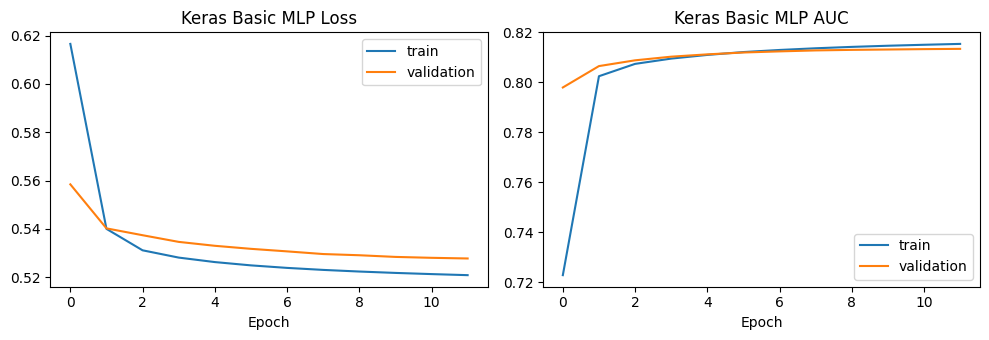

In [11]:
def plot_history(history, title, output_path):
    history_df = pd.DataFrame(history.history)
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
    axes[0].plot(history_df["loss"], label="train")
    axes[0].plot(history_df["val_loss"], label="validation")
    axes[0].set_title(f"{title} Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()
    axes[1].plot(history_df["auc"], label="train")
    axes[1].plot(history_df["val_auc"], label="validation")
    axes[1].set_title(f"{title} AUC")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()
    fig.tight_layout()
    fig.savefig(output_path, dpi=160)
    plt.show()


plot_history(
    keras_history, "Keras Basic MLP", FIGURE_DIR / "keras_basic_mlp_training_curves.png"
)

Output cho thấy điều gì?

Curves giúp kiểm tra mô hình học ổn định hay overfit. Khoảng cách train/validation là tín hiệu quan trọng hơn một epoch đơn lẻ.


# 12. Keras Evaluation

Cell này làm gì?

Đánh giá baseline Keras trên validation set bằng threshold chọn từ validation F1, gồm Accuracy, Precision, Recall, F1, ROC-AUC, confusion matrix và classification report.


In [12]:
keras_val_prob = keras_baseline.predict(
    X_valid, batch_size=BATCH_SIZE, verbose=0
).ravel()
keras_threshold, keras_threshold_table = select_threshold(y_valid_np, keras_val_prob)
keras_metrics = evaluate_probabilities(y_valid_np, keras_val_prob, keras_threshold)
keras_report = classification_report(
    y_valid_np.astype(int),
    (keras_val_prob >= keras_threshold).astype(int),
    output_dict=True,
    zero_division=0,
)

keras_result = {
    "Model": "M1 Basic MLP",
    "Framework": "Keras",
    **keras_metrics,
    "Params": int(keras_baseline.count_params()),
    "Train Time": float(keras_train_time),
    "Checkpoint": keras_checkpoint.relative_to(PROJECT_ROOT).as_posix(),
}

save_json(METRIC_DIR / "keras_basic_mlp_validation_metrics.json", keras_result)
keras_threshold_table.to_csv(METRIC_DIR / "keras_basic_mlp_thresholds.csv", index=False)
pd.DataFrame(keras_report).T.to_csv(
    METRIC_DIR / "keras_basic_mlp_classification_report.csv"
)

display(pd.DataFrame([keras_result]).drop(columns=["Checkpoint"]))
display(
    pd.DataFrame(
        confusion_matrix(y_valid_np, (keras_val_prob >= keras_threshold).astype(int)),
        index=["Actual 0", "Actual 1"],
        columns=["Pred 0", "Pred 1"],
    )
)
display(pd.DataFrame(keras_report).T.round(4))

,Model,Framework,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC,TN,FP,FN,TP,Params,Train Time
0,M1 Basic MLP,Keras,0.62,0.780266,0.365387,0.636454,0.464249,0.813402,22940,5537,1821,3188,3521,15.04973


,Pred 0,Pred 1
Actual 0,22940,5537
Actual 1,1821,3188


,precision,recall,f1-score,support
0,0.9265,0.8056,0.8618,28477.0000
1,0.3654,0.6365,0.4642,5009.0000
accuracy,0.7803,0.7803,0.7803,0.7803
macro avg,0.6459,0.7210,0.6630,33486.0000
weighted avg,0.8425,0.7803,0.8023,33486.0000


Output cho thấy điều gì?

Validation metrics dùng nhiều góc nhìn, không chỉ accuracy. Với bài toán diabetes, false negatives đáng chú ý vì là các ca có diabetes/risk nhưng model dự đoán âm tính; tuy vậy đây vẫn là phân tích trên survey dataset, không phải chẩn đoán y khoa.


# 13. Deep Learning with PyTorch

Cell này làm gì?

Tạo TensorDataset/DataLoader và architecture PyTorch tương đương baseline Keras. Trước khi train, chạy một batch qua model để kiểm tra input/logits shape.


In [13]:
torch.set_num_threads(max(1, min(4, os.cpu_count() or 1)))

train_ds = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    torch.tensor(y_train_np.reshape(-1, 1), dtype=torch.float32),
)
valid_ds = TensorDataset(
    torch.tensor(X_valid, dtype=torch.float32),
    torch.tensor(y_valid_np.reshape(-1, 1), dtype=torch.float32),
)
test_ds = TensorDataset(
    torch.tensor(X_test, dtype=torch.float32),
    torch.tensor(y_test_np.reshape(-1, 1), dtype=torch.float32),
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)


class TorchMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.net(x)


def count_torch_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


torch_model = TorchMLP(input_dim).to(DEVICE)
features_batch, labels_batch = next(iter(train_loader))
with torch.no_grad():
    logits_batch = torch_model(features_batch.to(DEVICE))

print("Input feature batch shape:", tuple(features_batch.shape))
print("Logits batch shape:", tuple(logits_batch.shape))
print("PyTorch parameter count:", count_torch_params(torch_model))

Input feature batch shape: (4096, 21)
Logits batch shape: (4096, 1)
PyTorch parameter count: 3521


Output cho thấy điều gì?

Batch input có dạng `(batch, 21)` và logits có dạng `(batch, 1)`, đúng với binary classification. PyTorch model dùng architecture tương đương Keras baseline để so sánh framework công bằng hơn.


# 14. PyTorch Training

Cell này làm gì?

Train PyTorch baseline với loop thủ công, class imbalance dùng `pos_weight`, và lưu checkpoint tốt nhất theo validation ROC-AUC.


In [14]:
def torch_predict_prob(model, loader):
    model.eval()
    probs = []
    targets = []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            logits = model(xb)
            prob = torch.sigmoid(logits).cpu().numpy().ravel()
            probs.append(prob)
            targets.append(yb.numpy().ravel())
    return np.concatenate(targets), np.concatenate(probs)


neg_count = float((y_train_np == 0).sum())
pos_count = float((y_train_np == 1).sum())
criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([neg_count / pos_count], dtype=torch.float32, device=DEVICE)
)
optimizer = torch.optim.Adam(torch_model.parameters(), lr=1e-3)

torch_history_rows = []
best_auc = -np.inf
best_state = None
epochs_without_improvement = 0
start = time.perf_counter()

for epoch in range(1, MAX_EPOCHS + 1):
    torch_model.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        optimizer.zero_grad()
        logits = torch_model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        running_loss += float(loss.item()) * xb.size(0)

    train_loss = running_loss / len(train_loader.dataset)
    valid_y_epoch, valid_prob_epoch = torch_predict_prob(torch_model, valid_loader)
    valid_auc = roc_auc_score(valid_y_epoch, valid_prob_epoch)
    valid_threshold_epoch, _ = select_threshold(valid_y_epoch, valid_prob_epoch)
    valid_metrics_epoch = evaluate_probabilities(
        valid_y_epoch, valid_prob_epoch, valid_threshold_epoch
    )
    torch_history_rows.append(
        {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_auc": valid_auc,
            "val_f1": valid_metrics_epoch["F1"],
            "val_recall": valid_metrics_epoch["Recall"],
        }
    )
    print(
        f"Epoch {epoch:02d} - train_loss={train_loss:.4f} - val_auc={valid_auc:.4f} - val_f1={valid_metrics_epoch['F1']:.4f}"
    )

    if valid_auc > best_auc:
        best_auc = valid_auc
        best_state = {
            k: v.detach().cpu().clone() for k, v in torch_model.state_dict().items()
        }
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= PATIENCE:
            print("Early stopping triggered.")
            break

torch_train_time = time.perf_counter() - start
torch_model.load_state_dict(best_state)
torch_checkpoint = MODEL_DIR / "pytorch_basic_mlp_best.pt"
torch.save(
    {
        "model_state_dict": torch_model.state_dict(),
        "input_dim": input_dim,
        "feature_columns": feature_cols,
        "seed": SEED,
    },
    torch_checkpoint,
)
torch_history = pd.DataFrame(torch_history_rows)
torch_history.to_csv(METRIC_DIR / "pytorch_basic_mlp_history.csv", index=False)
print(f"PyTorch train time: {torch_train_time:.2f} seconds")
display(torch_history)

Epoch 01 - train_loss=1.0477 - val_auc=0.7952 - val_f1=0.4446


Epoch 02 - train_loss=0.9139 - val_auc=0.8082 - val_f1=0.4598


Epoch 03 - train_loss=0.9006 - val_auc=0.8102 - val_f1=0.4620


Epoch 04 - train_loss=0.8966 - val_auc=0.8115 - val_f1=0.4630


Epoch 05 - train_loss=0.8939 - val_auc=0.8124 - val_f1=0.4640


...

Epoch 09 - train_loss=0.8879 - val_auc=0.8139 - val_f1=0.4657


Epoch 10 - train_loss=0.8872 - val_auc=0.8137 - val_f1=0.4658


Epoch 11 - train_loss=0.8865 - val_auc=0.8139 - val_f1=0.4661


Epoch 12 - train_loss=0.8857 - val_auc=0.8140 - val_f1=0.4653
PyTorch train time: 201.64 seconds


,epoch,train_loss,val_auc,val_f1,val_recall
0,1,1.047733,0.795160,0.444584,0.638251
1,2,0.913929,0.808227,0.459786,0.604312
2,3,0.900621,0.810219,0.461996,0.635855
3,4,0.896598,0.811488,0.463016,0.659213
4,5,0.893852,0.812393,0.464019,0.594729
5,6,0.891650,0.812734,0.465324,0.634258
6,7,0.889982,0.813395,0.465933,0.646436
7,8,0.888664,0.813330,0.466169,0.623078
8,9,0.887924,0.813883,0.465735,0.625474
9,10,0.887173,0.813697,0.465821,0.663206


Output cho thấy điều gì?

Loop PyTorch hiển thị đầy đủ các bước `zero_grad`, forward, loss, backward và optimizer step. Checkpoint tốt nhất được chọn bằng validation ROC-AUC, không dùng test set.


# 15. PyTorch Evaluation

Cell này làm gì?

Đánh giá PyTorch baseline trên validation set với cùng protocol như Keras.


In [15]:
valid_y_torch, torch_val_prob = torch_predict_prob(torch_model, valid_loader)
torch_threshold, torch_threshold_table = select_threshold(valid_y_torch, torch_val_prob)
torch_metrics = evaluate_probabilities(valid_y_torch, torch_val_prob, torch_threshold)
torch_report = classification_report(
    valid_y_torch.astype(int),
    (torch_val_prob >= torch_threshold).astype(int),
    output_dict=True,
    zero_division=0,
)

torch_result = {
    "Model": "M1 Basic MLP",
    "Framework": "PyTorch",
    **torch_metrics,
    "Params": int(count_torch_params(torch_model)),
    "Train Time": float(torch_train_time),
    "Checkpoint": torch_checkpoint.relative_to(PROJECT_ROOT).as_posix(),
}

save_json(METRIC_DIR / "pytorch_basic_mlp_validation_metrics.json", torch_result)
torch_threshold_table.to_csv(
    METRIC_DIR / "pytorch_basic_mlp_thresholds.csv", index=False
)
pd.DataFrame(torch_report).T.to_csv(
    METRIC_DIR / "pytorch_basic_mlp_classification_report.csv"
)

display(pd.DataFrame([torch_result]).drop(columns=["Checkpoint"]))
display(
    pd.DataFrame(
        confusion_matrix(
            valid_y_torch, (torch_val_prob >= torch_threshold).astype(int)
        ),
        index=["Actual 0", "Actual 1"],
        columns=["Pred 0", "Pred 1"],
    )
)
display(pd.DataFrame(torch_report).T.round(4))

,Model,Framework,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC,TN,FP,FN,TP,Params,Train Time
0,M1 Basic MLP,PyTorch,0.62,0.776086,0.361952,0.651427,0.465345,0.814035,22725,5752,1746,3263,3521,201.637448


,Pred 0,Pred 1
Actual 0,22725,5752
Actual 1,1746,3263


,precision,recall,f1-score,support
0,0.9287,0.7980,0.8584,28477.0000
1,0.3620,0.6514,0.4653,5009.0000
accuracy,0.7761,0.7761,0.7761,0.7761
macro avg,0.6453,0.7247,0.6619,33486.0000
weighted avg,0.8439,0.7761,0.7996,33486.0000


Output cho thấy điều gì?

PyTorch được đánh giá trên cùng validation set và cùng cách chọn threshold theo F1. Vì framework, initialization và optimizer implementation có khác biệt nhỏ, một run không đủ để kết luận framework nào tốt hơn về bản chất.


# 16. Keras vs PyTorch Comparison

Cell này làm gì?

So sánh baseline MLP Keras và PyTorch bằng cùng metric validation.


In [16]:
framework_comparison = pd.DataFrame([keras_result, torch_result])[
    [
        "Framework",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC",
        "Params",
        "Train Time",
        "Threshold",
    ]
].sort_values("F1", ascending=False)
framework_comparison.to_csv(METRIC_DIR / "keras_vs_pytorch_comparison.csv", index=False)
display(framework_comparison.round(4))

,Framework,Accuracy,Precision,Recall,F1,ROC-AUC,Params,Train Time,Threshold
1,PyTorch,0.7761,0.3620,0.6514,0.4653,0.8140,3521,201.6374,0.62
0,Keras,0.7803,0.3654,0.6365,0.4642,0.8134,3521,15.0497,0.62


Output cho thấy điều gì?

Bảng chỉ so sánh hai implementation baseline trong điều kiện hiện tại. Chênh lệch nhỏ có thể đến từ initialization, training loop và numerical behavior; không nên kết luận framework nào intrinsically better từ một run.


# 17. Architecture Experiments

Cell này làm gì?

Train các architecture MLP phù hợp dữ liệu tabular: M1 Basic MLP, M2 BatchNorm MLP, M3 Residual MLP, M4 Residual MLP + Feature Attention. CNN không được ép vào dữ liệu BRFSS vì feature order không có local structure tự nhiên.


In [17]:
def compile_binary_model(model):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.AUC(name="auc"),
        ],
    )
    return model


def build_batchnorm_mlp(input_dim, name="M2_BatchNorm_MLP"):
    inputs = keras.Input(shape=(input_dim,), name="health_indicator_vector")
    x = layers.Dense(64, use_bias=False, name="dense_64")(inputs)
    x = layers.BatchNormalization(name="bn_64")(x)
    x = layers.Activation("relu", name="relu_64")(x)
    x = layers.Dense(32, use_bias=False, name="dense_32")(x)
    x = layers.BatchNormalization(name="bn_32")(x)
    x = layers.Activation("relu", name="relu_32")(x)
    outputs = layers.Dense(1, activation="sigmoid", name="diabetes_probability")(x)
    return compile_binary_model(keras.Model(inputs, outputs, name=name))


def residual_block(x, units, block_name):
    shortcut = x
    y = layers.Dense(units, activation="relu", name=f"{block_name}_dense_a")(x)
    y = layers.Dense(units, name=f"{block_name}_dense_b")(y)
    x = layers.Add(name=f"{block_name}_add")([shortcut, y])
    return layers.Activation("relu", name=f"{block_name}_relu")(x)


def build_residual_mlp(input_dim, name="M3_Residual_MLP"):
    inputs = keras.Input(shape=(input_dim,), name="health_indicator_vector")
    x = layers.Dense(64, activation="relu", name="input_projection")(inputs)
    x = residual_block(x, 64, "residual_1")
    x = residual_block(x, 64, "residual_2")
    x = layers.Dense(32, activation="relu", name="dense_32")(x)
    outputs = layers.Dense(1, activation="sigmoid", name="diabetes_probability")(x)
    return compile_binary_model(keras.Model(inputs, outputs, name=name))


def build_attention_residual_mlp(input_dim, name="M4_Residual_MLP_Feature_Attention"):
    inputs = keras.Input(shape=(input_dim,), name="health_indicator_vector")
    attention = layers.Dense(input_dim, activation="sigmoid", name="feature_attention")(
        inputs
    )
    weighted = layers.Multiply(name="attention_weighted_features")([inputs, attention])
    x = layers.Dense(64, activation="relu", name="input_projection")(weighted)
    x = residual_block(x, 64, "residual_1")
    x = residual_block(x, 64, "residual_2")
    x = layers.Dense(32, activation="relu", name="dense_32")(x)
    outputs = layers.Dense(1, activation="sigmoid", name="diabetes_probability")(x)
    return compile_binary_model(keras.Model(inputs, outputs, name=name))


def evaluate_keras_model(model, model_key, checkpoint_path, train_time):
    val_prob = model.predict(X_valid, batch_size=BATCH_SIZE, verbose=0).ravel()
    threshold, threshold_table = select_threshold(y_valid_np, val_prob)
    metrics = evaluate_probabilities(y_valid_np, val_prob, threshold)
    result = {
        "Model": model.name.replace("_", " "),
        "Framework": "Keras",
        **metrics,
        "Params": int(model.count_params()),
        "Train Time": float(train_time),
        "Checkpoint": checkpoint_path.relative_to(PROJECT_ROOT).as_posix(),
    }
    save_json(METRIC_DIR / f"{model_key}_validation_metrics.json", result)
    threshold_table.to_csv(METRIC_DIR / f"{model_key}_thresholds.csv", index=False)
    return result


architecture_results = [keras_result]
architecture_histories = {"M1 Basic MLP": keras_history}
trained_keras_models = {"M1 Basic MLP": keras_baseline}

for model_key, builder in [
    ("m2_batchnorm_mlp", build_batchnorm_mlp),
    ("m3_residual_mlp", build_residual_mlp),
    ("m4_attention_residual_mlp", build_attention_residual_mlp),
]:
    keras.backend.clear_session()
    tf.random.set_seed(SEED)
    model = builder(input_dim)
    print("\nTraining", model.name, "with", model.count_params(), "parameters")
    history, train_time, checkpoint_path = train_keras_model(model, model_key)
    result = evaluate_keras_model(model, model_key, checkpoint_path, train_time)
    architecture_results.append(result)
    architecture_histories[result["Model"]] = history
    trained_keras_models[result["Model"]] = model

cnn_investigation = pd.DataFrame(
    [
        {
            "Investigation": "CNN on BRFSS tabular features",
            "Decision": "Not trained as a candidate model",
            "Reason": "Feature columns do not have meaningful local ordering; Conv1D/Conv2D would create artificial structure.",
        }
    ]
)
display(cnn_investigation)


Training M2_BatchNorm_MLP with 3809 parameters


Epoch 1/12


39/39 - 7s - 188ms/step - accuracy: 0.5479 - auc: 0.7373 - loss: 0.6222 - val_accuracy: 0.6990 - val_auc: 0.7870 - val_loss: 0.5817


Epoch 2/12


39/39 - 1s - 30ms/step - accuracy: 0.6798 - auc: 0.7987 - loss: 0.5430 - val_accuracy: 0.7311 - val_auc: 0.8002 - val_loss: 0.5136


...

Epoch 9/12


39/39 - 2s - 40ms/step - accuracy: 0.7082 - auc: 0.8170 - loss: 0.5189 - val_accuracy: 0.7053 - val_auc: 0.8108 - val_loss: 0.5269


Epoch 10/12


39/39 - 2s - 39ms/step - accuracy: 0.7094 - auc: 0.8178 - loss: 0.5179 - val_accuracy: 0.7064 - val_auc: 0.8108 - val_loss: 0.5255


,Investigation,Decision,Reason
0,CNN on BRFSS tabular features,Not trained as a candidate model,Feature columns do not have meaningful local o...


Output cho thấy điều gì?

Các experiment giữ cùng split, preprocessing, seed và training budget. CNN được xử lý như phần discovery/toy operation, không đưa vào model chính vì không có cơ sở spatial/sequential trên raw representation.


# 18. Improved Model Comparison

Cell này làm gì?

So sánh M1-M4 theo validation metrics và chọn ứng viên tốt nhất bằng validation F1.


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Params,Train Time,Threshold
2,M3 Residual MLP,0.7885,0.3739,0.6135,0.4647,0.8121,20161,21.5447,0.63
0,M1 Basic MLP,0.7803,0.3654,0.6365,0.4642,0.8134,3521,15.0497,0.62
3,M4 Residual MLP Feature Attention,0.7806,0.3654,0.6337,0.4635,0.8108,20623,28.2295,0.62
1,M2 BatchNorm MLP,0.7969,0.3822,0.5802,0.4608,0.8104,3809,24.5703,0.65


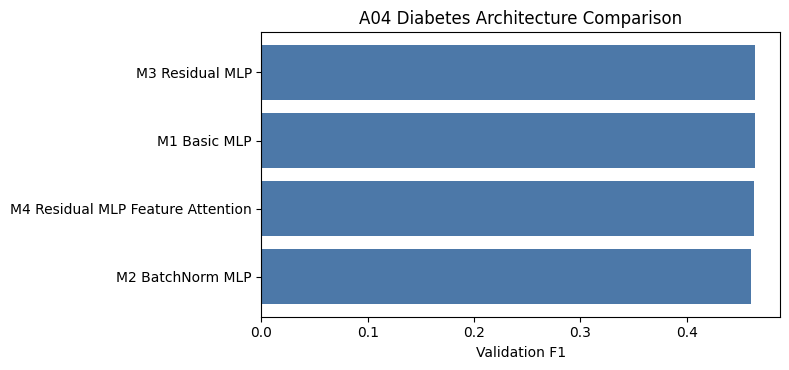

Best validation model: M3 Residual MLP
Best validation F1: 0.4647


In [18]:
architecture_comparison = pd.DataFrame(architecture_results)[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC",
        "Params",
        "Train Time",
        "Threshold",
        "Checkpoint",
    ]
].sort_values("F1", ascending=False)
architecture_comparison.to_csv(METRIC_DIR / "architecture_comparison.csv", index=False)

display(architecture_comparison.drop(columns=["Checkpoint"]).round(4))

fig, ax = plt.subplots(figsize=(8, 3.8))
plot_df = architecture_comparison.sort_values("F1")
ax.barh(plot_df["Model"], plot_df["F1"], color="#4C78A8")
ax.set_xlabel("Validation F1")
ax.set_title("A04 Diabetes Architecture Comparison")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "architecture_comparison_f1.png", dpi=160)
plt.show()

best_validation_row = architecture_comparison.iloc[0].to_dict()
print("Best validation model:", best_validation_row["Model"])
print("Best validation F1:", round(best_validation_row["F1"], 4))

Output cho thấy điều gì?

Bảng xếp hạng theo validation F1 vì dataset mất cân bằng và chỉ accuracy sẽ thiên về class 0. Trade-off cần đọc cùng Precision/Recall: recall cao hơn thường giảm false negatives nhưng có thể tăng false positives.


# 19. Representation Inspection

Cell này làm gì?

Inspect representation bên trong: activation của hidden layer cho model tốt nhất và attention weights nếu M4 được train.


,HiddenLayer,ActivationShape,MeanActivation,StdActivation,ZeroRate
0,input_projection,"(1024, 64)",0.2749,0.4159,0.4951


,Feature,MeanAttention,StdAttention
13,GenHlth,0.5384,0.2017
18,Age,0.5207,0.1526
2,CholCheck,0.5189,0.1770
0,HighBP,0.5174,0.1817
3,BMI,0.5143,0.1773
10,HvyAlcoholConsump,0.5059,0.1894
1,HighChol,0.5044,0.2168
6,HeartDiseaseorAttack,0.5037,0.1980
5,Stroke,0.5029,0.1965
4,Smoker,0.5016,0.1974


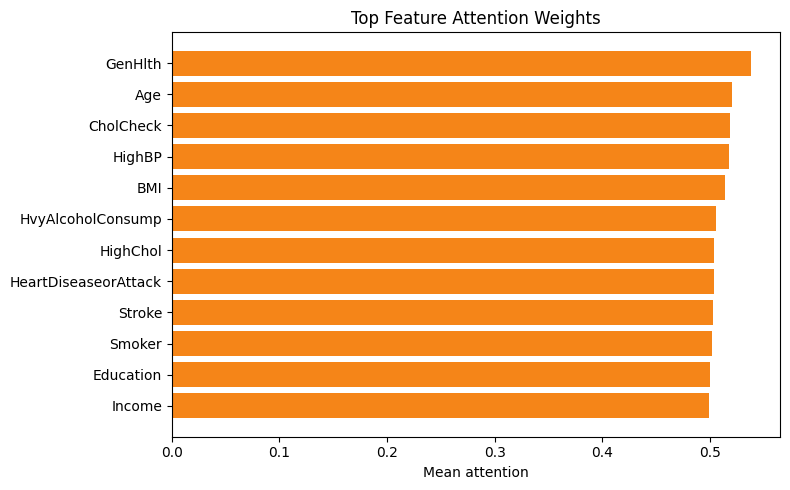

In [19]:
best_model_name = best_validation_row["Model"]
best_checkpoint_path = PROJECT_ROOT / best_validation_row["Checkpoint"]
best_validation_model = keras.models.load_model(best_checkpoint_path)

hidden_layer = None
for layer in best_validation_model.layers:
    if isinstance(layer, layers.Dense) and getattr(layer, "units", None) != 1:
        hidden_layer = layer.name
        break

if hidden_layer is not None:
    activation_model = keras.Model(
        best_validation_model.input,
        best_validation_model.get_layer(hidden_layer).output,
    )
    sample_activations = activation_model.predict(
        X_valid[:1024], batch_size=1024, verbose=0
    )
    activation_summary = pd.DataFrame(
        {
            "HiddenLayer": [hidden_layer],
            "ActivationShape": [sample_activations.shape],
            "MeanActivation": [float(sample_activations.mean())],
            "StdActivation": [float(sample_activations.std())],
            "ZeroRate": [float((np.abs(sample_activations) < 1e-8).mean())],
        }
    )
    display(activation_summary.round(4))

attention_model_path = MODEL_DIR / "m4_attention_residual_mlp_best.keras"
if attention_model_path.exists():
    attention_model = keras.models.load_model(attention_model_path)
    attention_extractor = keras.Model(
        attention_model.input, attention_model.get_layer("feature_attention").output
    )
    attention_values = attention_extractor.predict(
        X_valid[:5000], batch_size=4096, verbose=0
    )
    attention_summary = pd.DataFrame(
        {
            "Feature": feature_cols,
            "MeanAttention": attention_values.mean(axis=0),
            "StdAttention": attention_values.std(axis=0),
        }
    ).sort_values("MeanAttention", ascending=False)
    attention_summary.to_csv(METRIC_DIR / "feature_attention_summary.csv", index=False)
    display(attention_summary.head(10).round(4))
    fig, ax = plt.subplots(figsize=(8, 5))
    top_attention = attention_summary.head(12).sort_values("MeanAttention")
    ax.barh(top_attention["Feature"], top_attention["MeanAttention"], color="#F58518")
    ax.set_title("Top Feature Attention Weights")
    ax.set_xlabel("Mean attention")
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / "feature_attention_weights.png", dpi=160)
    plt.show()

Output cho thấy điều gì?

Hidden activations cho biết tabular vector được model biến đổi thành representation dày hơn trước output. Nếu có attention summary, đó là inspection phụ trợ về trọng số tương đối của feature trong M4, không phải bằng chứng nhân quả y khoa.


# 20. Error Analysis

Cell này làm gì?

Phân tích lỗi trên validation set: false positives, false negatives và high-confidence errors của model được chọn theo validation.


In [20]:
best_val_prob = best_validation_model.predict(
    X_valid, batch_size=BATCH_SIZE, verbose=0
).ravel()
best_threshold = float(best_validation_row["Threshold"])
best_val_pred = (best_val_prob >= best_threshold).astype(int)

error_df = X_valid_raw.reset_index(drop=True).copy()
error_df["y_true"] = y_valid_np.astype(int)
error_df["prob_diabetes"] = best_val_prob
error_df["y_pred"] = best_val_pred
error_df["confidence"] = np.where(best_val_pred == 1, best_val_prob, 1 - best_val_prob)
error_df["error_type"] = np.select(
    [
        (error_df["y_true"] == 0) & (error_df["y_pred"] == 1),
        (error_df["y_true"] == 1) & (error_df["y_pred"] == 0),
    ],
    ["False Positive", "False Negative"],
    default="Correct",
)

error_summary = (
    error_df["error_type"]
    .value_counts()
    .rename_axis("ErrorType")
    .reset_index(name="Count")
)
high_conf_errors = (
    error_df[error_df["error_type"] != "Correct"]
    .sort_values("confidence", ascending=False)
    .head(10)
)
fp_fn_profile = (
    error_df[error_df["error_type"].isin(["False Positive", "False Negative"])]
    .groupby("error_type")[feature_cols]
    .mean()
    .T
)

error_summary.to_csv(METRIC_DIR / "validation_error_summary.csv", index=False)
high_conf_errors.to_csv(
    METRIC_DIR / "validation_high_confidence_errors.csv", index=False
)
fp_fn_profile.to_csv(METRIC_DIR / "validation_fp_fn_feature_means.csv")

display(error_summary)
display(
    high_conf_errors[[TARGET for TARGET in []]]
    if False
    else high_conf_errors[
        [
            "y_true",
            "y_pred",
            "prob_diabetes",
            "confidence",
            "error_type",
            "HighBP",
            "HighChol",
            "BMI",
            "GenHlth",
            "Age",
        ]
    ]
)
display(
    fp_fn_profile.loc[
        ["HighBP", "HighChol", "BMI", "GenHlth", "DiffWalk", "Age", "Income"]
    ].round(3)
)

,ErrorType,Count
0,Correct,26405
1,False Positive,5145
2,False Negative,1936


,y_true,y_pred,prob_diabetes,confidence,error_type,HighBP,HighChol,BMI,GenHlth,Age
11224,1,0,0.002890,0.997110,False Negative,0,0.0,32.0,1.0,4
17305,1,0,0.010992,0.989008,False Negative,0,0.0,18.0,1.0,4
32632,1,0,0.011362,0.988638,False Negative,0,0.0,22.0,1.0,1
2242,1,0,0.011840,0.988160,False Negative,0,0.0,32.0,3.0,4
19987,1,0,0.017484,0.982516,False Negative,0,0.0,22.0,1.0,2
24866,1,0,0.017817,0.982183,False Negative,0,0.0,22.0,2.0,2
26529,1,0,0.020074,0.979926,False Negative,0,0.0,23.0,1.0,4
7857,1,0,0.022629,0.977371,False Negative,0,0.0,22.0,1.0,1
4846,1,0,0.023830,0.976170,False Negative,0,0.0,23.0,2.0,1
15469,1,0,0.028717,0.971283,False Negative,0,0.0,22.0,1.0,7


error_type,False Negative,False Positive
HighBP,0.460,0.874
HighChol,0.439,0.743
BMI,29.457,32.418
GenHlth,2.612,3.362
DiffWalk,0.165,0.375
Age,8.658,9.965
Income,6.702,5.848


Output cho thấy điều gì?

False negatives là nhóm cần chú ý trong bài toán diabetes vì model bỏ sót class 1 trên validation. High-confidence errors giúp nhận diện các vùng dữ liệu model tự tin nhưng sai; các nhận xét này chỉ dùng cho phân tích mô hình, không phải khuyến nghị lâm sàng.


# 21. Final Model

Cell này làm gì?

Load checkpoint tốt nhất theo validation, evaluate test set đúng một lần, rồi lưu final model và metrics.


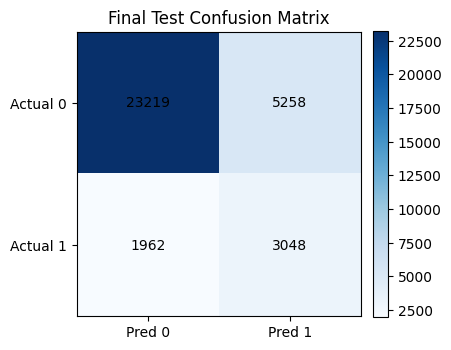

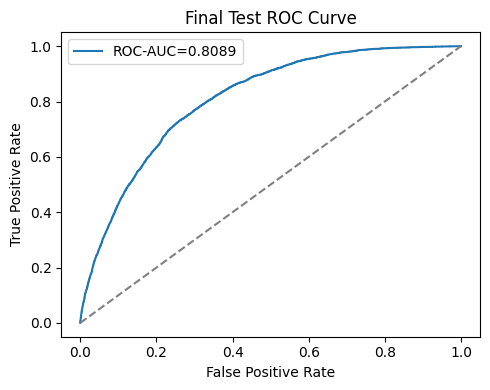

,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC,TN,FP,FN,TP
0,0.63,0.7844,0.367,0.6084,0.4578,0.8089,23219,5258,1962,3048


,precision,recall,f1-score,support
0,0.9221,0.8154,0.8654,28477.0000
1,0.3670,0.6084,0.4578,5010.0000
accuracy,0.7844,0.7844,0.7844,0.7844
macro avg,0.6445,0.7119,0.6616,33487.0000
weighted avg,0.8390,0.7844,0.8045,33487.0000


In [21]:
final_model = keras.models.load_model(best_checkpoint_path)
test_prob = final_model.predict(X_test, batch_size=BATCH_SIZE, verbose=0).ravel()
final_threshold = float(best_validation_row["Threshold"])
final_metrics = evaluate_probabilities(y_test_np, test_prob, final_threshold)
final_pred = (test_prob >= final_threshold).astype(int)
final_report = classification_report(
    y_test_np.astype(int), final_pred, output_dict=True, zero_division=0
)

final_model_path = MODEL_DIR / "final_model.keras"
final_model.save(final_model_path)

final_payload = {
    "selected_model": best_validation_row["Model"],
    "selection_metric": "Validation F1",
    "decision_threshold": final_threshold,
    "test_metrics": final_metrics,
    "final_model_path": final_model_path.relative_to(PROJECT_ROOT).as_posix(),
    "source_checkpoint": best_checkpoint_path.relative_to(PROJECT_ROOT).as_posix(),
}
save_json(METRIC_DIR / "final_test_metrics.json", final_payload)
pd.DataFrame(final_report).T.to_csv(METRIC_DIR / "final_classification_report.csv")

final_cm = confusion_matrix(y_test_np, final_pred)
fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(final_cm, cmap="Blues")
ax.set_xticks([0, 1], labels=["Pred 0", "Pred 1"])
ax.set_yticks([0, 1], labels=["Actual 0", "Actual 1"])
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(final_cm[i, j]), ha="center", va="center", color="black")
ax.set_title("Final Test Confusion Matrix")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "final_confusion_matrix.png", dpi=160)
plt.show()

fpr, tpr, _ = roc_curve(y_test_np, test_prob)
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(fpr, tpr, label=f"ROC-AUC={final_metrics['ROC-AUC']:.4f}")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Final Test ROC Curve")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "final_roc_curve.png", dpi=160)
plt.show()

display(pd.DataFrame([final_payload["test_metrics"]]).round(4))
display(pd.DataFrame(final_report).T.round(4))

Output cho thấy điều gì?

Đây là kết quả test cuối cùng của model đã chọn bằng validation. `M3 Residual MLP` dùng threshold 0.63; test Accuracy 0.7844, Precision 0.3670, Recall 0.6084, F1 0.4578, ROC-AUC 0.8089.


# 22. A03 vs A04 Comparison

Cell này làm gì?

Đọc artifacts A03 nếu có và so sánh dataset/workflow/metrics với A04. Không kết luận A04 tốt hơn chỉ vì score khác, vì dataset đã đổi.


In [22]:
if A03_METADATA_PATH.exists():
    with A03_METADATA_PATH.open("r", encoding="utf-8") as f:
        a03_metadata = json.load(f)
else:
    a03_metadata = {}

if A03_COMPARISON_PATH.exists():
    a03_comparison = pd.read_csv(A03_COMPARISON_PATH)
    a03_best = a03_comparison.sort_values("F1", ascending=False).iloc[0].to_dict()
else:
    a03_comparison = pd.DataFrame()
    a03_best = a03_metadata.get("metrics", {})
    a03_best["Model"] = a03_metadata.get("selected_model")

a03_vs_a04 = pd.DataFrame(
    [
        {
            "Aspect": "Dataset",
            "A03": a03_metadata.get("dataset_name", "CDC BRFSS 2015 balanced"),
            "A04": dataset_metadata["dataset_name"],
        },
        {
            "Aspect": "Rows used",
            "A03": "69,057 after duplicate removal in A03 notebook/artifacts",
            "A04": f"{len(df_clean):,} after duplicate removal",
        },
        {
            "Aspect": "Features",
            "A03": a03_metadata.get("feature_count", 21),
            "A04": len(feature_cols),
        },
        {
            "Aspect": "Class balance",
            "A03": "Approximately balanced",
            "A04": f"Positive rate {y.mean():.2%} after duplicate removal",
        },
        {
            "Aspect": "Best/final model",
            "A03": a03_best.get("Model", a03_metadata.get("selected_model")),
            "A04": final_payload["selected_model"],
        },
        {
            "Aspect": "F1",
            "A03": a03_best.get("F1", a03_metadata.get("metrics", {}).get("F1")),
            "A04": final_metrics["F1"],
        },
        {
            "Aspect": "ROC-AUC",
            "A03": a03_best.get(
                "ROC-AUC", a03_metadata.get("metrics", {}).get("ROC-AUC")
            ),
            "A04": final_metrics["ROC-AUC"],
        },
    ]
)
a03_vs_a04.to_csv(METRIC_DIR / "a03_vs_a04_comparison.csv", index=False)
display(a03_vs_a04)

,Aspect,A03,A04
0,Dataset,CDC Diabetes Health Indicators / BRFSS 2015 ba...,BRFSS 2021 Diabetes Health Indicators - Binary...
1,Rows used,"69,057 after duplicate removal in A03 notebook...","223,243 after duplicate removal"
2,Features,21,21
3,Class balance,Approximately balanced,Positive rate 14.96% after duplicate removal
4,Best/final model,Improved DNN,M3 Residual MLP
5,F1,0.771184,0.457795
6,ROC-AUC,0.819238,0.808909


Output cho thấy điều gì?

A03 và A04 cùng bài toán nhưng khác dataset: A03 cân bằng hơn, A04 thực tế hơn và mất cân bằng hơn. Vì vậy metric không chứng minh deep learning intrinsically better/worse; nó chỉ mô tả workflow và kết quả trên dữ liệu A04 đã chọn.


# 23. Final Results

Cell này làm gì?

Tổng hợp kết quả cuối, lưu metadata A04 của notebook và liệt kê artifacts đã tạo.


In [23]:
final_results = pd.DataFrame(
    [
        {
            "Dataset": dataset_metadata["dataset_name"],
            "RowsRaw": len(df_raw),
            "RowsAfterDedup": len(df_clean),
            "Features": len(feature_cols),
            "Target": TARGET,
            "SelectedModel": final_payload["selected_model"],
            "Threshold": final_threshold,
            "Accuracy": final_metrics["Accuracy"],
            "Precision": final_metrics["Precision"],
            "Recall": final_metrics["Recall"],
            "F1": final_metrics["F1"],
            "ROC-AUC": final_metrics["ROC-AUC"],
            "FinalModelPath": final_model_path.relative_to(PROJECT_ROOT).as_posix(),
        }
    ]
)
final_results.to_csv(METRIC_DIR / "final_results.csv", index=False)

notebook_metadata = {
    "assignment": "Assignment 04",
    "domain": "Diabetes",
    "task": "Binary classification: patient health indicators -> diabetes / diabetes risk",
    "dataset_name": dataset_metadata["dataset_name"],
    "source": dataset_metadata["source"],
    "source_url": dataset_metadata["source_url"],
    "license": dataset_metadata["license"],
    "target": TARGET,
    "raw_samples": int(len(df_raw)),
    "samples_after_duplicate_removal": int(len(df_clean)),
    "features": int(len(feature_cols)),
    "numerical_features": numerical_features,
    "categorical_features": categorical_features,
    "missing_values_total": int(df_raw.isna().sum().sum()),
    "duplicates_removed": int(len(df_raw) - len(df_clean)),
    "class_distribution_after_dedup": y.value_counts()
    .sort_index()
    .astype(int)
    .to_dict(),
    "split": {
        "train": int(len(y_train)),
        "validation": int(len(y_valid)),
        "test": int(len(y_test)),
    },
    "preprocessing": "Median imputation and StandardScaler fitted on training data only.",
    "representation": "Tabular vector representation, shape (samples, features).",
    "cnn_methodology": "CNN not used as production model because feature order is not spatial/sequential.",
    "models_tested": architecture_comparison["Model"].tolist(),
    "framework_baselines": framework_comparison["Framework"].tolist(),
    "selection_metric": "Validation F1",
    "selected_model": final_payload["selected_model"],
    "decision_threshold": final_threshold,
    "test_metrics": final_metrics,
    "artifacts": {
        "models": sorted(
            [
                p.relative_to(PROJECT_ROOT).as_posix()
                for p in MODEL_DIR.glob("*")
                if p.is_file()
            ]
        ),
        "metrics": sorted(
            [
                p.relative_to(PROJECT_ROOT).as_posix()
                for p in METRIC_DIR.glob("*")
                if p.is_file()
            ]
        ),
        "figures": sorted(
            [
                p.relative_to(PROJECT_ROOT).as_posix()
                for p in FIGURE_DIR.glob("*")
                if p.is_file()
            ]
        ),
    },
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "limitations": [
        "BRFSS is survey/indicator data, not a direct clinical diagnosis workflow.",
        "A04 class imbalance makes accuracy alone misleading.",
        "A03 and A04 metrics are not directly comparable because the datasets differ.",
        "CNN is demonstrated only on toy tensors because tabular feature columns have no justified local ordering.",
    ],
}
save_json(ARTIFACT_DIR / "metadata.json", notebook_metadata)
save_json(METRIC_DIR / "notebook_facts.json", notebook_metadata)

artifact_listing = []
for folder in [MODEL_DIR, METRIC_DIR, FIGURE_DIR]:
    for path in sorted(folder.glob("*")):
        if path.is_file():
            artifact_listing.append(
                {
                    "Path": path.relative_to(PROJECT_ROOT).as_posix(),
                    "SizeMB": round(path.stat().st_size / (1024 * 1024), 3),
                }
            )

display(final_results.round(4))
display(pd.DataFrame(artifact_listing))

,Dataset,RowsRaw,RowsAfterDedup,Features,Target,SelectedModel,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC,FinalModelPath
0,BRFSS 2021 Diabetes Health Indicators - Binary...,236378,223243,21,Diabetes_binary,M3 Residual MLP,0.63,0.7844,0.367,0.6084,0.4578,0.8089,pipeline04/diabetes/models/final_model.keras


,Path,SizeMB
0,pipeline04/diabetes/models/final_model.keras,0.287
1,pipeline04/diabetes/models/m1_basic_mlp_best.k...,0.068
2,pipeline04/diabetes/models/m2_batchnorm_mlp_be...,0.083
3,pipeline04/diabetes/models/m3_residual_mlp_bes...,0.288
4,pipeline04/diabetes/models/m4_attention_residu...,0.300
5,pipeline04/diabetes/models/preprocessor.joblib,0.004
6,pipeline04/diabetes/models/pytorch_basic_mlp_b...,0.017
7,pipeline04/diabetes/metrics/a03_vs_a04_compari...,0.000
8,pipeline04/diabetes/metrics/architecture_compa...,0.001
9,pipeline04/diabetes/metrics/feature_attention_...,0.001


Output cho thấy điều gì?

Bảng cuối ghi lại dataset, model được chọn, threshold và test metrics thật. Artifact listing xác nhận notebook đã lưu model, metrics, figures và metadata cho phase Diabetes A04; recorded training/evaluation time khoảng 306.08 giây.
